<!-- NB_DOC_INTRO_V1 -->
> 📚 **Documentation thematique** : [docs/03_ML.md](docs/03_ML.md) (Ml)
> 📖 **Inventaire global** : [docs/INVENTAIRE.md](docs/INVENTAIRE.md)
> 🗂️ **README projet** : [README.md](README.md)

## A quoi sert ce notebook

Comparaison du comportement des modeles face aux NaN : HistGradientBoosting et XGBoost gerent natif, RF/SVM/LinReg NON.

---


# Comportement des modèles face aux NaN

> Quel modèle gère nativement les valeurs manquantes, et lequel nécessite une imputation préalable ?

## Tableau de référence

| Modèle | Gère NaN nativement ? | Stratégie interne |
|---|:---:|---|
| **`HistGradientBoostingClassifier/Regressor`** (sklearn) | ✅ | Direction par défaut apprise à chaque split |
| **`XGBoost`** (`tree_method='hist'`) | ✅ | Direction par défaut |
| **`LightGBM`** | ✅ | Direction par défaut |
| **`CatBoost`** | ✅ | Traite NaN comme catégorie séparée |
| **`RandomForestClassifier/Regressor`** (sklearn) | ❌ | Erreur à `fit` — imputer avant |
| **`GradientBoostingClassifier/Regressor`** (sklearn legacy) | ❌ | Erreur |
| **`LinearRegression`, `LogisticRegression`** | ❌ | Erreur |
| **`SVC`, `KNeighborsClassifier`** | ❌ | Erreur |
| **Réseaux de neurones (PyTorch/Keras)** | ❌ | NaN propagés → loss NaN |

> 💡 **Conseil** : préférer `HistGradientBoosting` / XGBoost / LightGBM si tu as > 5% de NaN, c'est plus rapide et souvent plus précis qu'imputer puis fit un autre modèle.

## Stratégies d'imputation (sklearn)

| Méthode | Lib | Quand |
|---|---|---|
| `SimpleImputer(strategy='mean')` | sklearn | Quanti, distribution proche normale |
| `SimpleImputer(strategy='median')` | sklearn | Quanti, distribution asymétrique / outliers |
| `SimpleImputer(strategy='most_frequent')` | sklearn | Quali |
| `SimpleImputer(strategy='constant', fill_value=-1)` | sklearn | Marquer "manquant" sans assumer |
| `KNNImputer(n_neighbors=5)` | sklearn | Quanti, structure géométrique (rapproche par voisinage) |
| `IterativeImputer` (MICE) | sklearn (experimental) | Modélise chaque colonne avec les autres |
| `missingpy.MissForest` | external | RF-based, traite mixte |

## Règle d'or — **JAMAIS imputer avant le split** (data leakage)

```python
# ❌ MAUVAIS : imputation sur tout le df → fuite des stats du test dans le train
df['x'] = df['x'].fillna(df['x'].mean())
X_train, X_test = train_test_split(df, ...)

# ✅ BON : imputer dans un Pipeline qui sait fit sur train, transform sur test
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression()),
])
pipe.fit(X_train, y_train)  # imputer apprend la mediane sur train uniquement
pipe.score(X_test, y_test)
```

## Mécanismes de manquement (MCAR / MAR / MNAR)

| Type | Signifie | Exemple | Implication |
|---|---|---|---|
| **MCAR** (Missing Completely At Random) | Manquement indépendant de tout | Le capteur tombe en panne aléatoirement | Imputation simple OK |
| **MAR** (Missing At Random) | Manquement dépend des features observées | Hommes répondent moins à "salaire" que femmes (genre observé) | Imputation via les autres features (IterativeImputer, MICE) |
| **MNAR** (Missing Not At Random) | Manquement dépend de la valeur manquante elle-même | Riches ne déclarent pas leurs gros revenus | **Le plus pénible** — imputer biaise. Modéliser la cause. |

## Voir aussi
- [docs/01_STRUCTURES.md](./docs/01_STRUCTURES.md) — section preprocessing
- [Structures_Preprocessing.ipynb](./Structures_Preprocessing.ipynb) — pratique en détail


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import accuracy_score

In [2]:
# Charger le jeu de données Boston Housing
boston_data = fetch_openml(name="boston", version=2)

# Créer un DataFrame à partir des données
X, y = pd.DataFrame(boston_data.data, columns=boston_data.feature_names) , boston_data.target

/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


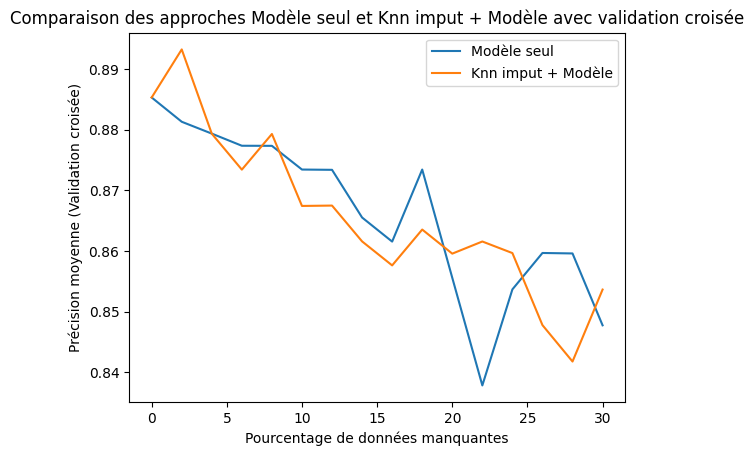

In [7]:
# Listes pour stocker les résultats
percentages_missing = list(range(0, 31, 2))
accuracy_approach1_list = []
accuracy_approach2_list = []

# Définition du nombre de partitions (4 dans ce cas)
num_partitions = 4
kf = KFold(n_splits=num_partitions, shuffle=True, random_state=42)

# Boucle sur les différents pourcentages de données manquantes
for percent_missing in percentages_missing:
    # Initialisation des listes pour stocker les résultats de chaque partition
    accuracy_approach1_cv = []
    accuracy_approach2_cv = []

    # Boucle sur les différentes partitions
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Création de quelques valeurs manquantes artificielles
        X_train_missing = X_train.copy()
        X_test_missing = X_test.copy()

        for col in X.columns:
            missing_mask_train = np.random.rand(X_train.shape[0]) < (percent_missing / 100)
            missing_mask_test = np.random.rand(X_test.shape[0]) < (percent_missing / 100)

            X_train_missing.loc[missing_mask_train, col] = np.nan
            X_test_missing.loc[missing_mask_test, col] = np.nan

        # Approche 1 : Modèle qui gère les données manquantes
        model_approach1 = RandomForestClassifier(random_state=42)
        imputer_approach1 = SimpleImputer(strategy='mean')
        X_train_approach1 = imputer_approach1.fit_transform(X_train_missing)
        X_test_approach1 = imputer_approach1.transform(X_test_missing)
        model_approach1.fit(X_train_approach1, y_train)
        accuracy_approach1 = accuracy_score(y_test, model_approach1.predict(X_test_approach1))
        accuracy_approach1_cv.append(accuracy_approach1)

        # Approche 2 : Imputation avec k-NN + Modèle qui gère les données manquantes
        model_approach2 = RandomForestClassifier(random_state=42)
        imputer_approach2 = KNNImputer(n_neighbors=3)
        X_train_approach2 = imputer_approach2.fit_transform(X_train_missing)
        X_test_approach2 = imputer_approach2.transform(X_test_missing)
        model_approach2.fit(X_train_approach2, y_train)
        accuracy_approach2 = accuracy_score(y_test, model_approach2.predict(X_test_approach2))
        accuracy_approach2_cv.append(accuracy_approach2)

    # Calcul de la moyenne des précisions pour chaque approche
    mean_accuracy_approach1 = np.mean(accuracy_approach1_cv)
    mean_accuracy_approach2 = np.mean(accuracy_approach2_cv)

    # Ajout des résultats à la liste
    accuracy_approach1_list.append(mean_accuracy_approach1)
    accuracy_approach2_list.append(mean_accuracy_approach2)

# Tracé du graphique
plt.plot(percentages_missing, accuracy_approach1_list, label='Modèle seul')
plt.plot(percentages_missing, accuracy_approach2_list, label='Knn imput + Modèle')
plt.xlabel('Pourcentage de données manquantes')
plt.ylabel('Précision moyenne (Validation croisée)')
plt.title('Comparaison des approches Modèle seul et Knn imput + Modèle avec validation croisée')
plt.legend()
plt.show()

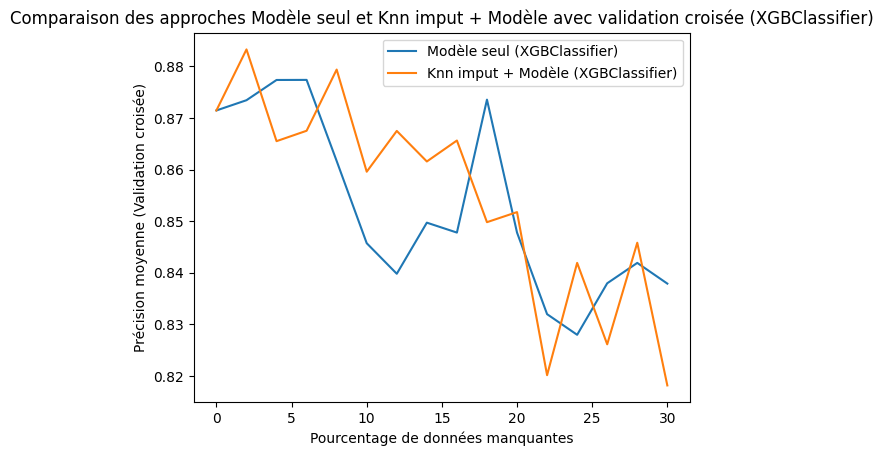

In [6]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Convertir les classes en valeurs numériques
label_encoder = LabelEncoder()
y_numeric = label_encoder.fit_transform(y)

# Convertir les variables catégorielles en numériques
categorical_cols = X.select_dtypes(include=['category']).columns
for col in categorical_cols:
    X[col] = label_encoder.fit_transform(X[col])

# Listes pour stocker les résultats
percentages_missing = list(range(0, 31, 2))
accuracy_approach1_list = []
accuracy_approach2_list = []

# Définition du nombre de partitions (4 dans ce cas)
num_partitions = 4
kf = KFold(n_splits=num_partitions, shuffle=True, random_state=42)

# Boucle sur les différents pourcentages de données manquantes
for percent_missing in percentages_missing:
    # Initialisation des listes pour stocker les résultats de chaque partition
    accuracy_approach1_cv = []
    accuracy_approach2_cv = []

    # Boucle sur les différentes partitions
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y_numeric[train_index], y_numeric[test_index]

        # Création de quelques valeurs manquantes artificielles
        X_train_missing = X_train.copy()
        X_test_missing = X_test.copy()

        for col in X.columns:
            missing_mask_train = np.random.rand(X_train.shape[0]) < (percent_missing / 100)
            missing_mask_test = np.random.rand(X_test.shape[0]) < (percent_missing / 100)

            X_train_missing.loc[missing_mask_train, col] = np.nan
            X_test_missing.loc[missing_mask_test, col] = np.nan

        # Approche 1 : Modèle qui gère les données manquantes
        model_approach1 = XGBClassifier(random_state=42, enable_categorical=True)
        model_approach1.fit(X_train_missing, y_train)
        accuracy_approach1 = accuracy_score(y_test, model_approach1.predict(X_test_missing))
        accuracy_approach1_cv.append(accuracy_approach1)

        # Approche 2 : Imputation avec k-NN + Modèle qui gère les données manquantes
        model_approach2 = XGBClassifier(random_state=42, enable_categorical=True)
        imputer_approach2 = KNNImputer(n_neighbors=5)
        X_train_approach2 = imputer_approach2.fit_transform(X_train_missing)
        X_test_approach2 = imputer_approach2.transform(X_test_missing)
        model_approach2.fit(X_train_approach2, y_train)
        accuracy_approach2 = accuracy_score(y_test, model_approach2.predict(X_test_approach2))
        accuracy_approach2_cv.append(accuracy_approach2)

    # Calcul de la moyenne des précisions pour chaque approche
    mean_accuracy_approach1 = np.mean(accuracy_approach1_cv)
    mean_accuracy_approach2 = np.mean(accuracy_approach2_cv)

    # Ajout des résultats à la liste
    accuracy_approach1_list.append(mean_accuracy_approach1)
    accuracy_approach2_list.append(mean_accuracy_approach2)

# Tracé du graphique
plt.plot(percentages_missing, accuracy_approach1_list, label='Modèle seul (XGBClassifier)')
plt.plot(percentages_missing, accuracy_approach2_list, label='Knn imput + Modèle (XGBClassifier)')
plt.xlabel('Pourcentage de données manquantes')
plt.ylabel('Précision moyenne (Validation croisée)')
plt.title('Comparaison des approches Modèle seul et Knn imput + Modèle avec validation croisée (XGBClassifier)')
plt.legend()
plt.show()

---

## Conclusion pratique

Pour un **prototype rapide** :
1. Si > 5% de NaN : utilise **HistGradientBoostingClassifier** (sklearn) ou **LightGBM** → zéro effort d'imputation.
2. Si tu dois utiliser RF / SVM / DL : **`Pipeline` avec `SimpleImputer(strategy='median')`** est un excellent défaut.
3. Visualise toujours d'abord avec `missingno` : `import missingno as msno; msno.matrix(df)`.
